In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df=pd.read_csv("../data/RELIANCE_raw.csv", index_col=0, parse_dates=True)
print (df.shape)
print (df.head())

In [ ]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"]=df["Close"].rolling(window=50).mean()

print(df[["Close","SMA_20","SMA_50"]].head(60))

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df["Close"], label="Close", alpha=0.7)
plt.plot(df["SMA_20"], label="SMA 20", linewidth=1.5)
plt.plot(df["SMA_50"], label="SMA 50", linewidth=1.5)
plt.title("Reliance - Close vs Moving Averages")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df["EMA_20"]=df["Close"].ewm(span=20,adjust=False).mean()

plt.figure(figsize=(14, 5))
plt.plot(df["Close"], label="Close", alpha=0.5)
plt.plot(df["SMA_20"], label="SMA 20", linewidth=1.5)
plt.plot(df["EMA_20"], label="EMA 20", linewidth=1.5)
plt.title("SMA vs EMA - which reacts faster?")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def compute_rsi(series,period=14):
    delta=series.diff()
    gain=delta.where(delta>0,0)
    loss=-delta.where(delta<0,0)

    avg_gain=gain.rolling(window=period).mean()
    avg_loss=loss.rolling(window=period).mean()

    rs=avg_gain/avg_loss
    rsi=100*(rs/(1+rs))

    return rsi

df["RSI_14"] = compute_rsi(df["Close"])

plt.figure(figsize=(14, 4))
plt.plot(df["RSI_14"], color="purple")
plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
plt.title("Reliance - RSI (14 day)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

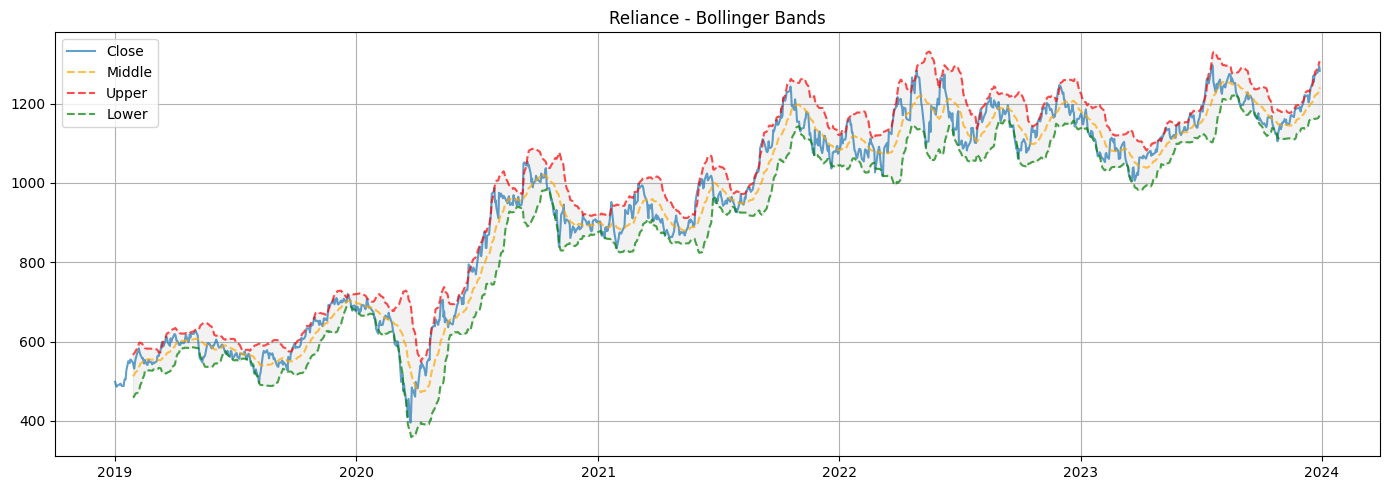

In [8]:
df["BB_Middle"]=df["Close"].rolling(window=20).mean()
df["BB_Std"]=df["Close"].rolling(window=20).std()
df["BB_Upper"]=df["BB_Middle"]+2*df["BB_Std"]
df["BB_Lower"]=df["BB_Middle"]-2*df["BB_Std"]


plt.figure(figsize=(14,5))
plt.plot(df["Close"], label="Close", alpha=0.7)
plt.plot(df["BB_Middle"], label="Middle", linestyle="--", alpha=0.7, color="orange")
plt.plot(df["BB_Upper"], label="Upper", linestyle="--", alpha=0.7, color="red")
plt.plot(df["BB_Lower"], label="Lower", linestyle="--", alpha=0.7, color="green")
plt.fill_between(df.index, df["BB_Upper"], df["BB_Lower"], alpha=0.1, color="grey")
plt.title("Reliance - Bollinger Bands")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



1) as we can see during covid crash there is expansion in bands as we know stock was volatile
2) What does it mean when price touches lower band? Stock at all time low of the past 20 days,
3) What does it mean when bands are narrow? Means std has not been that much and price has remained fairly constant in the past 20 days 

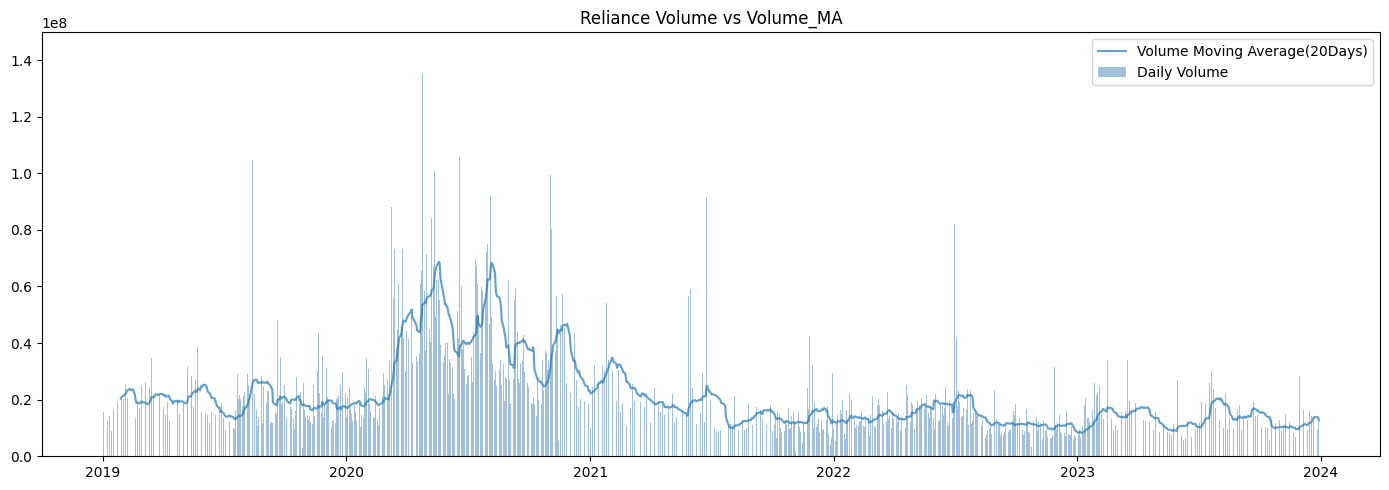

In [14]:
df["Volume_MA_20"]=df["Volume"].rolling(window=20).mean()
plt.figure(figsize=(14,5))
plt.plot(df["Volume_MA_20"], label="Volume Moving Average(20Days)",alpha=0.7)
plt.bar(df.index, df["Volume"], color="steelblue", alpha=0.5, label="Daily Volume")
plt.legend()
plt.title("Reliance Volume vs Volume_MA")
plt.tight_layout()
plt.show()


1) If today's volume is 3x the 20-day volume average, what does that suggest? It means that stock might be very volatile today compared to previous 20 days
2) Why is raw volume less useful than volume relative to its moving average? because the absoulte volume of a stock being traded on a day is of no use unless I have something to compare it to, to make my predictions about if the stock is more volatile today or less volatile. MA allows us to have that reference to compare todays volume with respect to previous 20 days.


In [27]:
#Target label most important feature for backtesting

df["Future_Close"]=df["Close"].shift(-5)
df["Target"]=(df["Future_Close"]>df["Close"]).astype(int)
percentage_ones = (df["Target"] == 1).mean() * 100
print(df[["Close", "Future_Close", "Target"]].head(10))
print("\nTarget distribution: ")
print(df["Target"].value_counts())
print(percentage_ones)
print("Number of days for 1: ", percentage_ones*((df.shape)[0])/100 )
print ("Number of days for 0: ", ((100-percentage_ones)*((df.shape)[0])/100))


                 Close  Future_Close  Target
2019-01-01  498.490570    491.220032       0
2019-01-02  491.998260    493.932617       1
2019-01-03  485.928345    492.487396       1
2019-01-04  488.551910    488.285156       0
2019-01-07  491.264557    487.729248       0
2019-01-08  491.220032    502.337189       1
2019-01-09  493.932617    505.116394       1
2019-01-10  492.487396    504.471619       1
2019-01-11  488.285156    526.661316       1
2019-01-14  487.729248    550.385193       1

Target distribution: 
Target
1    672
0    563
Name: count, dtype: int64
54.412955465587046
Number of days for 1:  672.0
Number of days for 0:  563.0


1) As we can see close from 5 days after match current Future_Close colomn
2) We can see that in the whole data 54.4129 percentage have target=1 ( I think yes as it is >50% means stock prise is rising though not drastically as it is only 4% over 50)
3) last 5 are nan because we dont have data to shift backward for them

""FUTURE_CLOSE IS ONLY USED TO CREATE THE LABEL. IT IS NEVER A FEATURE." or our model will learn to cheat if it gets this future coloumn"

In [29]:
df = df.dropna(subset=["Target"])
df = df.drop(columns=["Future_Close","BB_Middle","BB_Std"])
print(df.shape)
print(df.isnull().sum())
print(df.columns.tolist())
df.to_csv("../data/RELIANCE_features_v2.csv")
print("Saved")

(1235, 13)
Close            0
High             0
Low              0
Open             0
Volume           0
SMA_20          19
SMA_50          49
EMA_20           0
RSI_14          13
BB_Upper        19
BB_Lower        19
Volume_MA_20    19
Target           0
dtype: int64
['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 'BB_Upper', 'BB_Lower', 'Volume_MA_20', 'Target']
Saved


No of days where target=1 => 672
No of days where target-0 => 563